# Deep Learning with MNIST Dataset

This notebook builds and trains an artificial neural network (ANN) to recognize handwritten digits using the MNIST dataset.

## Import Libraries

Import TensorFlow and Keras for building neural networks.

In [1]:
import tensorflow as tf
from tensorflow import keras

## Load MNIST Dataset

Load the MNIST dataset containing 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is 28×28 pixels in grayscale.

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

## Step 3: Inspect Data Shape

Check the dimensions of the training and test datasets to understand the data structure.

In [3]:
print (X_train.shape)
print (X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


## Visualize Sample Digits

Display the first 10 training images with their true labels to understand the data better.

<Figure size 640x480 with 0 Axes>

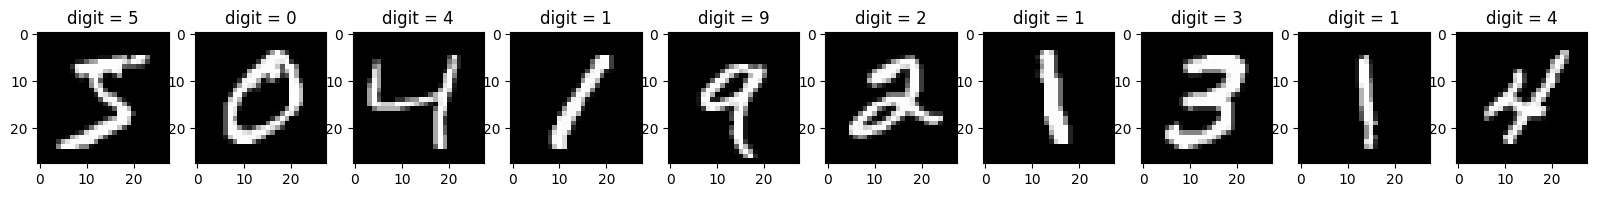

In [4]:
import matplotlib.pyplot as plt

plt.gray()
figure, axis = plt.subplots(ncols=10, figsize=(20, 20))
for index in range(10):
    axis[index].imshow(X_train[index])
    axis[index].set_title(f"digit = {y_train[index]}")

## Build and Compile the Neural Network

Create a sequential ANN with:
- **Input Layer**: 28×28 pixel images
- **Flatten Layer**: Converts 2D images to 1D vectors
- **Hidden Layer**: 100 neurons with sigmoid activation
- **Output Layer**: 10 neurons (digits 0-9) with sigmoid activation

Compile using Adam optimizer and sparse categorical crossentropy loss.

In [5]:
ann = keras.models.Sequential(
    [keras.layers.Input((28, 28)),
      keras.layers.Flatten(),
      keras.layers.Dense(100, activation='sigmoid'),
      keras.layers.Dense(10, activation='sigmoid')
    ])
ann.compile (
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


View the network architecture and parameter count.

In [6]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history1 = ann.fit(X_train, y_train, epochs=10, validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8360 - loss: 0.6113 - val_accuracy: 0.8893 - val_loss: 0.4059
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8867 - loss: 0.4004 - val_accuracy: 0.8953 - val_loss: 0.3762
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8979 - loss: 0.3493 - val_accuracy: 0.8994 - val_loss: 0.3367
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9004 - loss: 0.3353 - val_accuracy: 0.9067 - val_loss: 0.3156
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9061 - loss: 0.3144 - val_accuracy: 0.9148 - val_loss: 0.2958
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9099 - loss: 0.3010 - val_accuracy: 0.9129 - val_loss: 0.2957
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9104 - loss: 0.2970 - val_accuracy: 0.9139 - val_loss: 0.2889
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9080 - loss: 0.3034 - 

## Train the Neural Network

Train the ANN on the MNIST training data for 10 epochs using 30% of training data as validation. The model monitors both training and validation accuracy/loss during training.

In [7]:
history1 = ann.fit

### Check Fit Method Details

Display the documentation for the fit method to understand all available parameters and options.

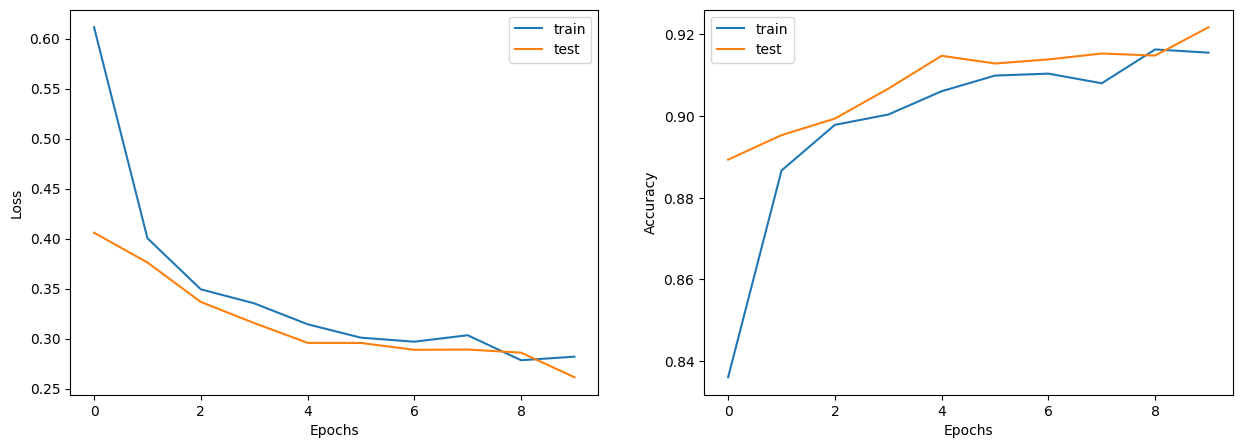

In [10]:
figure, axis = plt.subplots(ncols=2, figsize=(15, 5))
axis[0].plot(history1.history['loss'])
axis[0].plot(history1.history["val_loss"])
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("Loss")
axis[0].legend(["train", "test"])
axis[1].plot(history1.history['accuracy'])
axis[1].plot(history1.history["val_accuracy"])
axis[1].set_xlabel("Epochs")
axis[1].set_ylabel("Accuracy")
axis[1].legend(["train", "test"])
plt.show()

## Visualize Training History

Plot the training and validation loss and accuracy curves to analyze the model's learning progress over epochs.

In [11]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

## Inspect Sample Training Image

Display the first training image as a 28×28 pixel array to see the raw numerical representation of a handwritten digit.

In [12]:
train_evaluation = ann.evaluate(X_train, y_train)
test_evaluation = ann.evaluate(X_test, y_test)
print(f"Train Evaluation: {train_evaluation}")
print(f"Test Evaluation: {test_evaluation}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9244 - loss: 0.2551
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9246 - loss: 0.2547
Train Evaluation: [0.25514453649520874, 0.9243999719619751]
Test Evaluation: [0.2547212839126587, 0.9246000051498413]


##  Evaluate Model Performance

Evaluate the trained model on both training and test datasets to measure loss and accuracy metrics.

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

## Import Evaluation Tools

Import scikit-learn metrics and visualization tools for detailed model evaluation and confusion matrix analysis.

In [14]:
pred = ann.predict(X_test)
predictions = np.argmax(pred, axis=1)
predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

## Generate Predictions

Use the trained model to predict class probabilities for test images and convert them to predicted digit labels using argmax.

In [15]:
pred

array([[8.0684572e-02, 2.8737471e-04, 2.6341888e-01, ..., 9.9985349e-01,
        1.2771108e-02, 4.9680969e-01],
       [3.0256051e-01, 5.0127149e-01, 9.8901796e-01, ..., 1.6152912e-03,
        3.8442876e-02, 4.2011063e-05],
       [4.4699147e-04, 9.9854916e-01, 2.1562923e-01, ..., 2.9774616e-02,
        7.7497609e-02, 3.8873248e-03],
       ...,
       [6.7766418e-04, 4.3684542e-02, 3.4550792e-03, ..., 6.6054553e-02,
        2.2243832e-01, 3.3847192e-01],
       [6.9088556e-02, 3.2272540e-02, 6.7820604e-04, ..., 1.7925208e-04,
        7.3750126e-01, 2.8479767e-03],
       [6.3744080e-01, 1.5496756e-03, 6.3410008e-01, ..., 7.6687284e-04,
        5.3823858e-02, 1.2933312e-03]], dtype=float32)

In [16]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.97      0.99      0.98      1135
           2       0.93      0.92      0.92      1032
           3       0.89      0.91      0.90      1010
           4       0.90      0.93      0.92       982
           5       0.92      0.88      0.90       892
           6       0.94      0.94      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.88      0.90      0.89       974
           9       0.91      0.88      0.89      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## Classification Report

Display detailed classification metrics (precision, recall, F1-score) for each digit class on the test set to evaluate model performance per class.

Text(50.722222222222214, 0.5, 'Actual')

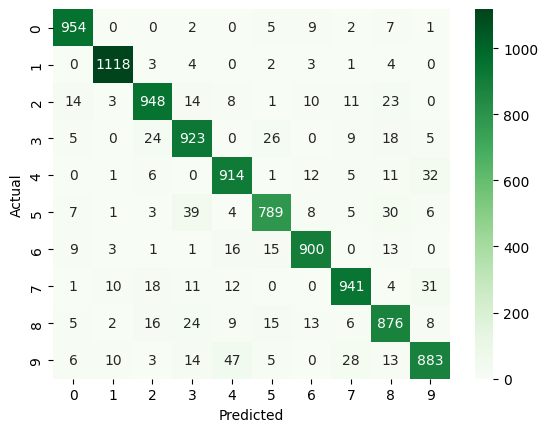

In [17]:
cm = tf.math.confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')

## Confusion Matrix Visualization

Create and visualize the confusion matrix as a heatmap to analyze which digits the model predicts correctly and which ones it confuses with each other.

In [18]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0
history2 = ann.fit(X_train_scaled, y_train, epochs=10, validation_split=0.3)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9390 - loss: 0.2182 - val_accuracy: 0.9434 - val_loss: 0.2029
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9474 - loss: 0.1800 - val_accuracy: 0.9493 - val_loss: 0.1789
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9547 - loss: 0.1554 - val_accuracy: 0.9540 - val_loss: 0.1618
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9612 - loss: 0.1335 - val_accuracy: 0.9576 - val_loss: 0.1488
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9666 - loss: 0.1140 - val_accuracy: 0.9613 - val_loss: 0.1343
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9723 - loss: 0.0974 - val_accuracy: 0.9630 - val_loss: 0.1240
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9768 - loss: 0.0826 - val_accuracy: 0.9667 - val_loss: 0.1124
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9801 - loss: 0.0704 - 

## Feature Scaling and Model Retraining

Normalize the pixel values to the range [0, 1] by dividing by 255.0. Retrain the ANN on the scaled data for 10 epochs to improve model performance with normalized inputs.

## Convolutional Neural Network (CNN)

Build a Convolutional Neural Network (CNN) model which is better suited for image data. 
CNNs use convolutional layers to detect local features like edges and patterns, making them more effective than fully-connected networks for image classification tasks like MNIST digit recognition.

In [19]:
cnn = keras.Sequential([
    keras.layers.Input((28,28,1)),
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### CNN Architecture Details

- `Input((28,28,1))`: grayscale 28×28 images with a single channel.
- `Conv2D(filters=32, kernel_size=(3,3), activation='relu')`: detects low-level features (edges, corners).
- `MaxPooling2D((2,2))`: reduces spatial dimensions and keeps strongest features.
- `Conv2D(filters=64, kernel_size=(3,3), activation='relu')`: learns higher-level, more complex features.
- `MaxPooling2D((2,2))`: further downsampling to reduce parameters and overfitting.
- `Flatten()`: converts 2D feature maps to a 1D vector for dense layers.
- `Dense(100, activation='relu')`: fully connected layer to combine features.
- `Dense(10, activation='softmax')`: output probabilities for the 10 digit classes.

In [20]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,926 (702.84 KB)

 Trainable params: 179,926 (702.84 KB)

 Non-trainable params: 0 (0.00 B)

### Display CNN Architecture

Show the summary of the CNN model structure including layers, output shapes, and parameter counts.

In [21]:
# Scale pixel values to [0,1] and add channel dimension for CNN input
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0
# add channel axis
X_train_scaled = X_train_scaled[..., None]
X_test_scaled = X_test_scaled[..., None]

# ensure correct dtype and train
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')
history3 = cnn.fit(X_train_scaled, y_train, epochs=10, validation_split=0.3, batch_size=32)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9518 - loss: 0.1565 - val_accuracy: 0.9796 - val_loss: 0.0655
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9844 - loss: 0.0507 - val_accuracy: 0.9852 - val_loss: 0.0484
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9889 - loss: 0.0354 - val_accuracy: 0.9867 - val_loss: 0.0434
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9923 - loss: 0.0254 - val_accuracy: 0.9877 - val_loss: 0.0417
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.9889 - val_loss: 0.0413
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9953 - loss: 0.0141 - val_accuracy: 0.9863 - val_loss: 0.0504
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.9959 - loss: 0.0119 - val_accuracy: 0.9878 - val_loss: 0.0491
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9964 -

### Train CNN Model on Scaled Data

Normalize pixel values to [0, 1] range and train the CNN for 10 epochs with 30% validation split to monitor performance.

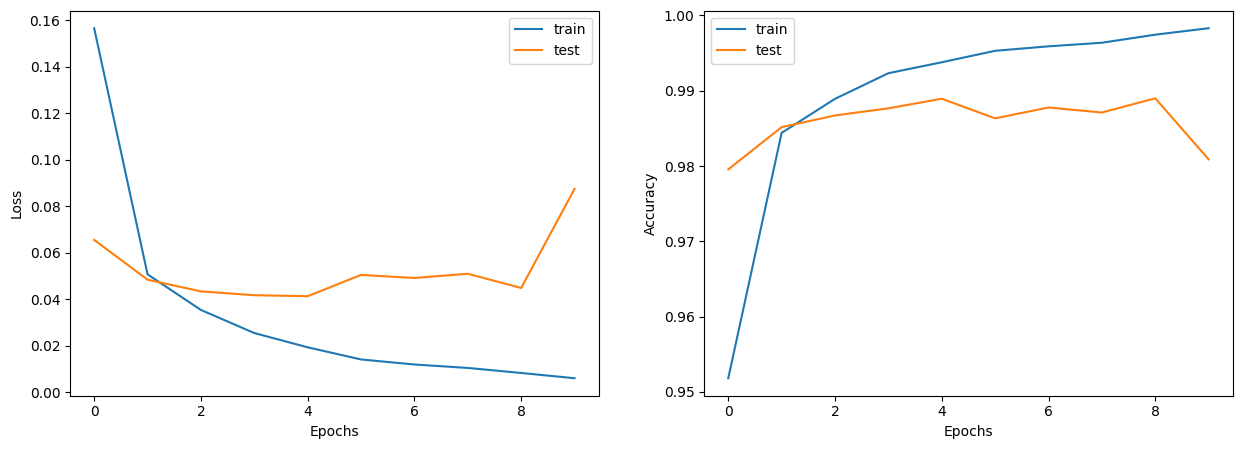

In [22]:
figure, axis = plt.subplots(ncols=2, figsize=(15, 5))
axis[0].plot(history3.history['loss'])
axis[0].plot(history3.history["val_loss"])
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("Loss")
axis[0].legend(["train", "test"])
axis[1].plot(history3.history['accuracy'])
axis[1].plot(history3.history["val_accuracy"])
axis[1].set_xlabel("Epochs")
axis[1].set_ylabel("Accuracy")
axis[1].legend(["train", "test"])
plt.show()

### Plot CNN Training History

Visualize the CNN's training and validation loss and accuracy across epochs to assess learning progress and detect overfitting.

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9894 - loss: 0.0415
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9828 - loss: 0.0767
Train Evaluation: [0.04145641252398491, 0.9893666505813599]
Test Evaluation: [0.07669757306575775, 0.9828000068664551]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       980
           1       1.00      0.99      0.99      1135
           2       0.94      1.00      0.97      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.96      0.99      0.97       958
           7       0.99      0.96      0.97      1028
           8       1.00      0.98      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98     

Text(50.722222222222214, 0.5, 'Actual')

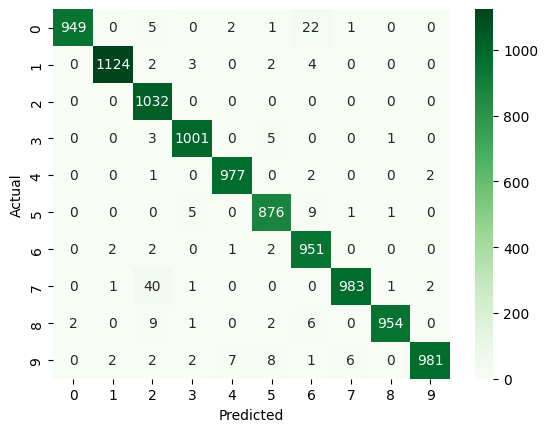

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# Evaluate the CNN on scaled data
train_evaluation = cnn.evaluate(X_train_scaled, y_train)
test_evaluation = cnn.evaluate(X_test_scaled, y_test)
print(f"Train Evaluation: {train_evaluation}")
print(f"Test Evaluation: {test_evaluation}")

# Generate CNN predictions and show classification report
pred_cnn = cnn.predict(X_test_scaled)
predictions_cnn = np.argmax(pred_cnn, axis=1)
print(classification_report(y_test, predictions_cnn))

# Confusion matrix heatmap
cm = tf.math.confusion_matrix(y_test, predictions_cnn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')

### CNN Evaluation

- Use `evaluate()` to compute loss and accuracy on training and test sets.
- Convert model outputs to class labels using `argmax` before classification reporting.
- Plot a confusion matrix to inspect per-class errors and confusions.